Import Libraries

In [23]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns

Generate Synthetic Data

In [24]:
np.random.seed(42)

In [25]:
n = 250

In [26]:
names = [f"Student_{i}" for i in range(1, n+1)]
genders = np.random.choice(['Male', 'Female'], n)
departments = np.random.choice(['CSE', 'IT', 'ECE'], n)
years = np.random.choice(['1st', '2nd', '3rd'], n)
maths = np.random.randint(35, 100, n)
science = np.random.randint(35, 100, n)
english = np.random.randint(35, 100, n)
attendance = np.random.randint(50, 101, n)
internal = np.random.randint(5, 26, n)

In [27]:
df = pd.DataFrame({
    'Student_ID': range(1, n+1),
    'Name': names,
    'Gender': genders,
    'Department': departments,
    'Year': years,
    'Maths': maths,
    'Science': science,
    'English': english,
    'Attendance (%)': attendance,
    'Internal Marks': internal
})

Feature Engineering

In [28]:
df['Total'] = df['Maths'] + df['Science'] + df['English']
df['Average'] = df['Total'] / 3

Grade Classification

In [29]:
def grade(avg):
    if avg >= 90:
        return 'A'
    elif avg >= 75:
        return 'B'
    elif avg >= 60:
        return 'C'
    else:
        return 'Fail'

df['Grade'] = df['Average'].apply(grade)

Save Dataset

In [30]:
df.to_csv("student_performance.csv", index=False)

print("Dataset Created Successfully!\n")
print(df.head())

Dataset Created Successfully!

   Student_ID       Name  Gender Department Year  Maths  Science  English  \
0           1  Student_1    Male         IT  1st     92       51       65   
1           2  Student_2  Female        CSE  2nd     78       43       40   
2           3  Student_3    Male        CSE  2nd     79       49       74   
3           4  Student_4    Male        CSE  2nd     66       58       46   
4           5  Student_5    Male        ECE  3rd     79       72       87   

   Attendance (%)  Internal Marks  Total    Average Grade  
0              81              24    208  69.333333     C  
1              85               9    161  53.666667  Fail  
2              99               8    202  67.333333     C  
3              53              16    170  56.666667  Fail  
4              76              24    238  79.333333     B  


 Basic EDA

In [31]:
print("\nSummary Statistics:\n")
print(df.describe())


Summary Statistics:

       Student_ID       Maths     Science     English  Attendance (%)  \
count  250.000000  250.000000  250.000000  250.000000      250.000000   
mean   125.500000   65.976000   66.668000   68.316000       74.116000   
std     72.312977   19.745556   18.203826   18.773436       14.199049   
min      1.000000   35.000000   35.000000   35.000000       50.000000   
25%     63.250000   48.250000   51.250000   51.000000       62.000000   
50%    125.500000   65.000000   67.000000   70.000000       73.000000   
75%    187.750000   84.000000   83.000000   84.750000       85.000000   
max    250.000000   99.000000   99.000000   99.000000      100.000000   

       Internal Marks       Total     Average  
count      250.000000  250.000000  250.000000  
mean        14.824000  200.960000   66.986667  
std          6.090435   34.092928   11.364309  
min          5.000000  122.000000   40.666667  
25%          9.000000  175.250000   58.416667  
50%         15.000000  201.00000

In [32]:
top_students = df.sort_values(by='Average', ascending=False).head(10)
print("\nTop 10 Students:\n", top_students[['Name', 'Average']])


Top 10 Students:
             Name    Average
35    Student_36  93.000000
149  Student_150  89.666667
135  Student_136  89.333333
188  Student_189  89.333333
60    Student_61  89.333333
136  Student_137  89.000000
157  Student_158  89.000000
58    Student_59  88.333333
151  Student_152  88.333333
89    Student_90  87.666667


In [33]:
low_students = df[df['Grade'] == 'Fail']
print("\nFail Students:\n", low_students[['Name', 'Average']])


Fail Students:
             Name    Average
1      Student_2  53.666667
3      Student_4  56.666667
10    Student_11  59.000000
12    Student_13  52.333333
20    Student_21  46.666667
..           ...        ...
235  Student_236  49.333333
236  Student_237  58.000000
239  Student_240  55.333333
245  Student_246  53.333333
247  Student_248  55.333333

[73 rows x 2 columns]


Group Analysis

In [34]:
print("\nDepartment-wise Performance:\n", df.groupby('Department')['Average'].mean())


Department-wise Performance:
 Department
CSE    66.722222
ECE    67.304878
IT     66.940476
Name: Average, dtype: float64


In [35]:
print("\nGender-wise Performance:\n", df.groupby('Gender')['Average'].mean())


Gender-wise Performance:
 Gender
Female    66.099462
Male      67.859788
Name: Average, dtype: float64


In [36]:
print("\nYear-wise Performance:\n", df.groupby('Year')['Average'].mean())


Year-wise Performance:
 Year
1st    68.103333
2nd    65.918803
3rd    66.592593
Name: Average, dtype: float64


Visualization

Bar Chart-Department

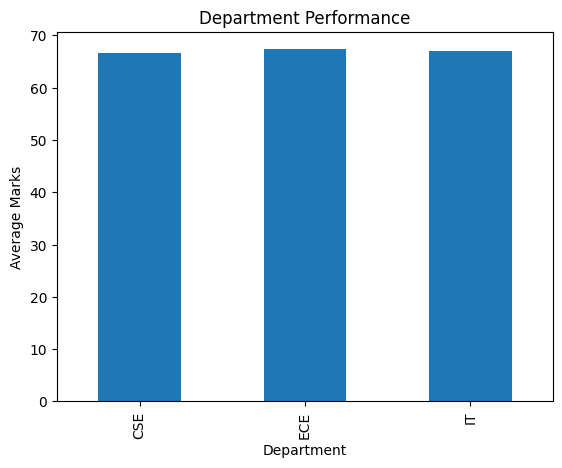

In [37]:
df.groupby('Department')['Average'].mean().plot(kind='bar', title="Department Performance")
plt.ylabel("Average Marks")
plt.show()

Pie Chart-Gender

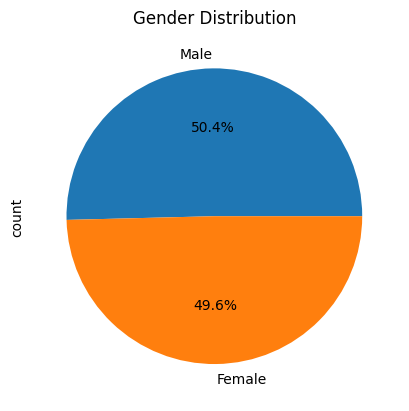

In [38]:
df['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%', title="Gender Distribution")
plt.show()

Histogram-Average Marks

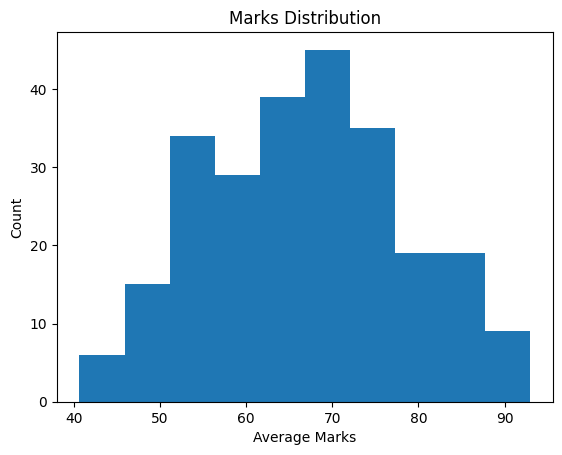

In [39]:
plt.hist(df['Average'], bins=10)
plt.title("Marks Distribution")
plt.xlabel("Average Marks")
plt.ylabel("Count")
plt.show()

 Scatter-Attendance vs Average

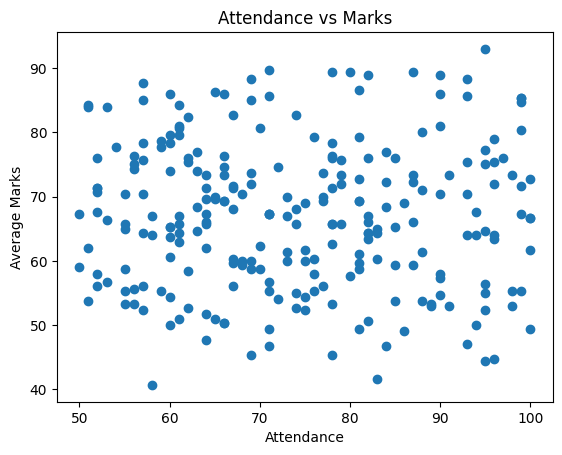

In [40]:
plt.scatter(df['Attendance (%)'], df['Average'])
plt.title("Attendance vs Marks")
plt.xlabel("Attendance")
plt.ylabel("Average Marks")
plt.show()

Scatter-Internal vs Average

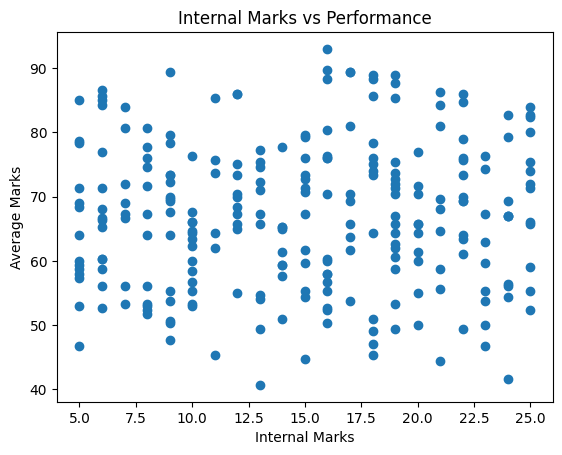

In [41]:
plt.scatter(df['Internal Marks'], df['Average'])
plt.title("Internal Marks vs Performance")
plt.xlabel("Internal Marks")
plt.ylabel("Average Marks")
plt.show()